In [1]:
!pip install -q transformers scikit-learn seaborn matplotlib

In [2]:
import pandas as pd
import numpy as np
import torch
import re
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import torch.nn.functional as F

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/myproject/TurnBackHoax_fiks.csv',
    encoding='latin1', sep=';', engine='python', on_bad_lines='skip'
)

df['text'] = df['judul'].fillna('') + " " + df['konten'].fillna('') + " " + df['ringkasan'].fillna('')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if len(text.split()) < 5:
        return ""
    return text

df['text'] = df['text'].apply(clean_text)
df = df[df['text'] != ""]

Mounted at /content/drive


In [4]:
# ambil beberapa contoh acak
sample_df = df.sample(5, random_state=42)

def raw_text(row):
    return (str(row['judul']) + " " + str(row['konten']) + " " + str(row['ringkasan']))

comparison = []

for _, row in sample_df.iterrows():
    before = raw_text(row)
    after = clean_text(before)
    comparison.append({
        "Sebelum": before[:200],
        "Sesudah": after[:200]
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

                                             Sebelum  \
0  [SALAH] Najwa Shihab Menangis ketika... BERHAT...   
1  [SALAH] Ketua KPU Hasyim Asyari... Innalilla...   
2  [PENIPUAN] Bantuan Untuk Masjid Oleh... (Tidak...   
3  [SALAH] Anjing Laut Berkepala Sapi Beredar seb...   
4  [SALAH] Bogor Hancur Ratusan Rumah... Bogor Ha...   

                                             Sesudah  
0  salah najwa shihab menangis ketika berhati mul...  
1  salah ketua kpu hasyim asy ari innalillahi wa ...  
2  penipuan bantuan untuk masjid oleh tidak ditam...  
3  salah anjing laut berkepala sapi beredar sebua...  
4  salah bogor hancur ratusan rumah bogor hancur ...  


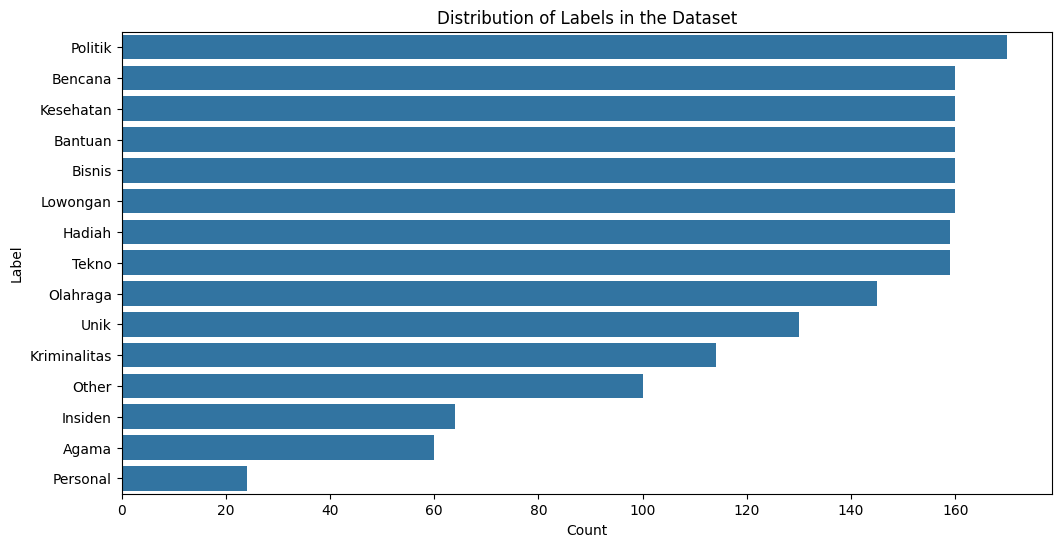

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(y='label', data=df, order=df['label'].value_counts().index)
plt.title('Distribution of Labels in the Dataset')
plt.xlabel('Count')
plt.ylabel('Label')
plt.show()

In [6]:
def augment(text):
    words = text.split()
    if len(words) > 6:
        i = random.randint(0, len(words)-2)
        words[i], words[i+1] = words[i+1], words[i]
    return " ".join(words)

df_aug = df.copy()
df_aug['text'] = df_aug['text'].apply(augment)

df = pd.concat([df, df_aug]).reset_index(drop=True)

In [7]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['label_enc'],
    test_size=0.2,
    stratify=df['label_enc'],
    random_state=42
)

In [8]:
print(df[['label', 'label_enc']].drop_duplicates().sort_values('label_enc'))

             label  label_enc
1756         Agama          0
489        Bantuan          1
319        Bencana          2
659         Bisnis          3
10          Hadiah          4
1672       Insiden          5
159      Kesehatan          6
1423  Kriminalitas          7
988       Lowongan          8
1088      Olahraga          9
1557         Other         10
1816      Personal         11
449        Politik         12
0            Tekno         13
1273          Unik         14


In [9]:
for i, label in enumerate(le.classes_):
    print(f"{i} → {label}")

0 → Agama
1 → Bantuan
2 → Bencana
3 → Bisnis
4 → Hadiah
5 → Insiden
6 → Kesehatan
7 → Kriminalitas
8 → Lowongan
9 → Olahraga
10 → Other
11 → Personal
12 → Politik
13 → Tekno
14 → Unik


In [10]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [11]:
class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        if self.alpha is not None:
            at = self.alpha[targets]
            loss = at * (1 - pt) ** self.gamma * ce_loss
        else:
            loss = (1 - pt) ** self.gamma * ce_loss

        return loss.mean()

In [12]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx])
        }

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
def train_eval(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(le.classes_)
    ).to(device)

    for param in model.base_model.embeddings.parameters():
        param.requires_grad = False

    train_dataset = TextDataset(train_texts, train_labels, tokenizer)
    val_dataset = TextDataset(val_texts, val_labels, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16)

    optimizer = AdamW(model.parameters(), lr=2e-5)

    loss_fn = FocalLoss(alpha=class_weights.to(device), gamma=2)

    for epoch in range(5):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            total_loss += loss.item()

        print(model_name, "Epoch", epoch+1, "Loss:", total_loss)

    model.eval()
    preds, true_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(pred)
            true_labels.extend(batch['labels'].numpy())

    acc = accuracy_score(true_labels, preds)
    f1 = f1_score(true_labels, preds, average='weighted')

    return acc, f1, preds, true_labels

In [15]:
indobert_acc, indobert_f1, indobert_preds, true_labels = train_eval("indobenchmark/indobert-base-p1")
mbert_acc, mbert_f1, mbert_preds, _ = train_eval("bert-base-multilingual-cased")

print("IndoBERT:", indobert_acc, indobert_f1)
print("mBERT:", mbert_acc, mbert_f1)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


bert-base-multilingual-cased Epoch 1 Loss: 310.77522256970406
bert-base-multilingual-cased Epoch 2 Loss: 139.1576818227768
bert-base-multilingual-cased Epoch 3 Loss: 64.56863352283835
bert-base-multilingual-cased Epoch 4 Loss: 29.74503635149449
bert-base-multilingual-cased Epoch 5 Loss: 15.321025862824172
IndoBERT: 0.9714285714285714 0.9713706770334661
mBERT: 0.9311688311688312 0.9310806216010648


In [16]:
ensemble = []

for p1, p2 in zip(indobert_preds, mbert_preds):
    if p1 == p2:
        ensemble.append(p1)
    else:
        ensemble.append(p1)

ensemble = np.array(ensemble)

ens_acc = accuracy_score(true_labels, ensemble)
ens_f1 = f1_score(true_labels, ensemble, average='weighted')

print("Ensemble:", ens_acc, ens_f1)

Ensemble: 0.9714285714285714 0.9713706770334661


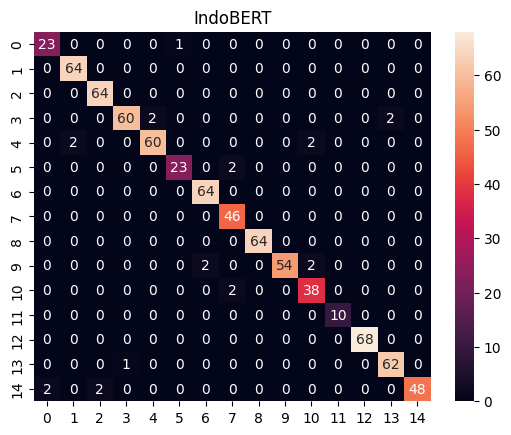

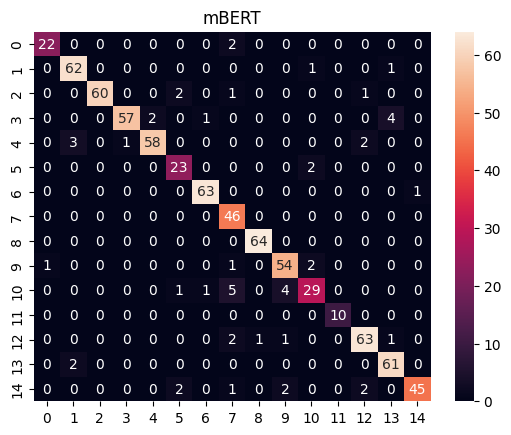

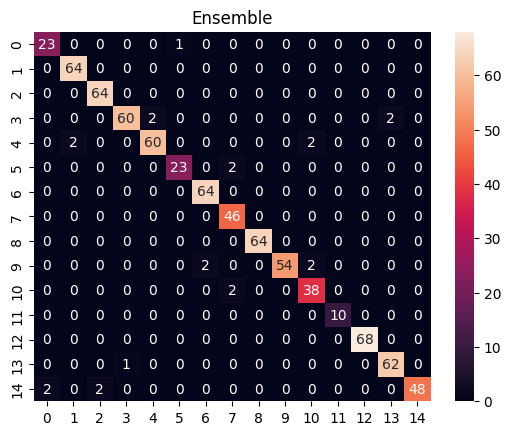

In [17]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.show()

plot_cm(true_labels, indobert_preds, "IndoBERT")
plot_cm(true_labels, mbert_preds, "mBERT")
plot_cm(true_labels, ensemble, "Ensemble")

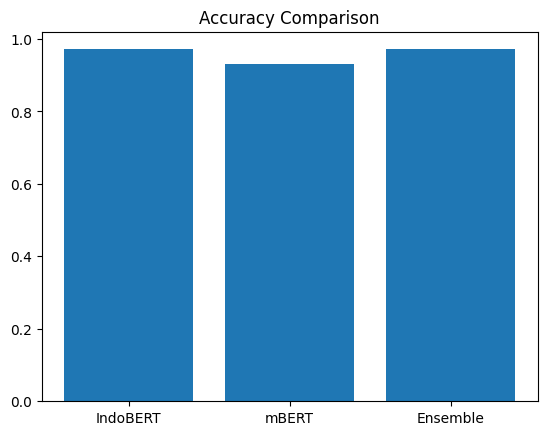

In [18]:
models = ["IndoBERT", "mBERT", "Ensemble"]
accuracy = [indobert_acc, mbert_acc, ens_acc]
f1 = [indobert_f1, mbert_f1, ens_f1]

plt.figure()
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_metrics(y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted')

    return acc, prec, rec, f1

In [20]:
indobert_acc, indobert_prec, indobert_rec, indobert_f1 = evaluate_metrics(true_labels, indobert_preds)

mbert_acc, mbert_prec, mbert_rec, mbert_f1 = evaluate_metrics(true_labels, mbert_preds)

ens_acc, ens_prec, ens_rec, ens_f1 = evaluate_metrics(true_labels, ensemble)

In [21]:
results_df = pd.DataFrame({
    "Model": ["IndoBERT", "mBERT", "Ensemble"],
    "Accuracy": [indobert_acc, mbert_acc, ens_acc],
    "Precision": [indobert_prec, mbert_prec, ens_prec],
    "Recall": [indobert_rec, mbert_rec, ens_rec],
    "F1 Score": [indobert_f1, mbert_f1, ens_f1]
})

print(results_df)

      Model  Accuracy  Precision    Recall  F1 Score
0  IndoBERT  0.971429   0.972270  0.971429  0.971371
1     mBERT  0.931169   0.934673  0.931169  0.931081
2  Ensemble  0.971429   0.972270  0.971429  0.971371


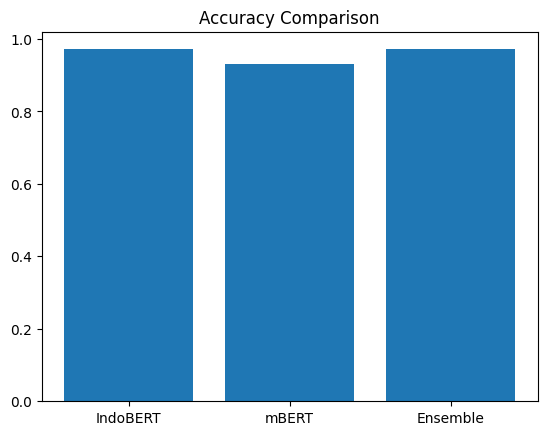

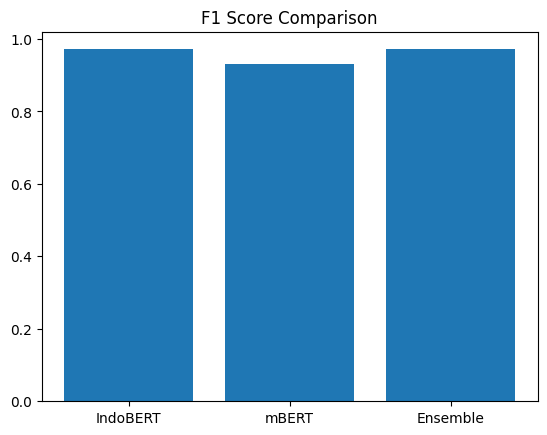

In [22]:
models = ["IndoBERT", "mBERT", "Ensemble"]

plt.figure()
plt.bar(models, [indobert_acc, mbert_acc, ens_acc])
plt.title("Accuracy Comparison")
plt.show()

plt.figure()
plt.bar(models, [indobert_f1, mbert_f1, ens_f1])
plt.title("F1 Score Comparison")
plt.show()

In [23]:
for i in range(5):
    print("Teks :", val_texts.iloc[i][:100])
    print("Label asli :", le.inverse_transform([true_labels[i]])[0])
    print("Prediksi   :", le.inverse_transform([indobert_preds[i]])[0])
    print("-"*50)

Teks : salah banten hancur lebur sekampung banten hancur lebur warga heboh sekampung mendadak ambrol gempa 
Label asli : Bencana
Prediksi   : Bencana
--------------------------------------------------
Teks : salah fenomena aphelion sebabkan suhu narasi pagi mulai besok jam kita akan mengalami narasi mulai p
Label asli : Unik
Prediksi   : Unik
--------------------------------------------------
Teks : salah masyarakat solo demo tolak beredar unggahan gambar arsip dari akun facebook ananto wijaya bere
Label asli : Politik
Prediksi   : Politik
--------------------------------------------------
Teks : tornado salah dan hujan es sumatera utara porak poranda tornado hujan es sapu sumatera utara porak p
Label asli : Bencana
Prediksi   : Bencana
--------------------------------------------------
Teks : penipuan pendaftaran rekrutmen pegawai bumn klaim mengenai tautan pendaftaran rekrutmen bersama bumn
Label asli : Lowongan
Prediksi   : Lowongan
--------------------------------------------------

In [24]:
import pandas as pd

sample_results = pd.DataFrame({
    "Text": val_texts[:10].values,
    "True": le.inverse_transform(true_labels[:10]),
    "Pred": le.inverse_transform(indobert_preds[:10])
})

print(sample_results)

                                                Text      True      Pred
0  salah banten hancur lebur sekampung banten han...   Bencana   Bencana
1  salah fenomena aphelion sebabkan suhu narasi p...      Unik      Unik
2  salah masyarakat solo demo tolak beredar ungga...   Politik   Politik
3  tornado salah dan hujan es sumatera utara pora...   Bencana   Bencana
4  penipuan pendaftaran rekrutmen pegawai bumn kl...  Lowongan  Lowongan
5  penipuan akun tiktok menawarkan pinjaman dot w...    Bisnis    Bisnis
6  salah tribunnews beritakan mui minta akun tikt...     Agama     Agama
7  penipuan pendaftaran bansos kemensos lewat aku...   Bantuan   Bantuan
8  penipuan pendaftaran lowongan kerja faktanya g...  Lowongan  Lowongan
9  penipuan bantuan lewat wa oleh saya h saifuddi...   Bantuan   Bantuan
